<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
The first task involves building a classification model to predict whether a retail transaction
is fraudulent. The dataset contains transaction information, and careful feature engineering is
required to avoid data leakage. All features must be computed using only information available
before the target event.
</div>

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Check / Install / Import Dependencies</h1>

In [48]:
import sys
import subprocess
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "openpyxl": "openpyxl"
}

def install_if_missing(pip_name, import_name):
    try:
        importlib.import_module(import_name)
        print(f"✅ {pip_name}")
    except ImportError:
        print(f"📦 Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

for pip_name, import_name in required_packages.items():
    install_if_missing(pip_name, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, cohen_kappa_score
)

print("✅ Minimal environment is ready.")


✅ pandas
✅ numpy
✅ scikit-learn
✅ matplotlib
✅ seaborn
✅ openpyxl
✅ Minimal environment is ready.


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Constants</h1>

In [58]:
# File paths
train_path = "data/task1_dataset/train.xlsx"
cv_path = "data/task1_dataset/student_test.xlsx"

BOOL_MAP = {
    "true": 1, "false": 0, "1": 1, "0": 0,
    "yes": 1, "no": 0, "y": 1, "n": 0, "t": 1, "f": 0
}

TARGET = "label"
IDCOL  = "id"

sentinel_map = {
    "transaction_amount": -99.99,
    "account_age_days": -30,
    "transaction_frequency_24h": -3,
    "avg_transaction_amount_7d": -1,
    "failed_transaction_count_24h": -2,
}

numeric_cols = [
    "transaction_amount",
    "transaction_frequency_24h",
    "avg_transaction_amount_7d",
    "failed_transaction_count_24h",
    "account_age_days"
]

bool_like_cols = [
    "is_international",
    "unusual_amount_flag",
    "multiple_transactions_short_time",
    "high_risk_device_flag"
]

categorical_cols = [
    "payment_method",
    "device_type",
    "location",
    "merchant_category"
]

drop_noise = ["transaction_id", "customer_id"]

cross_te_cols = [
    "sec_location",
    "sec_merchant",
    "sec_payment"
    ]


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Load Data + Initial EDA</h1>

In [50]:
# Load data
train_df = pd.read_excel(train_path)
cv_df = pd.read_excel(cv_path)
print("Data loaded successfully.\n")

Data loaded successfully.



<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Info + Missing Values + Duplicates</h1>

In [51]:
print("="*80)
print("TRAIN INFO")
print("="*80)
display(train_df.info())

print("\n" + "="*80)
print("TEST INFO")
print("="*80)
display(cv_df.info())

# Missing values summary
train_missing = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_percent": (train_df.isnull().sum() / len(train_df)) * 100
}).sort_values(by="missing_percent", ascending=False)

test_missing = pd.DataFrame({
    "missing_count": cv_df.isnull().sum(),
    "missing_percent": (cv_df.isnull().sum() / len(cv_df)) * 100
}).sort_values(by="missing_percent", ascending=False)

print("\n" + "="*80)
print("TRAIN MISSING VALUES")
print("="*80)
display(train_missing[train_missing["missing_count"] > 0])

print("\n" + "="*80)
print("TEST MISSING VALUES")
print("="*80)
display(test_missing[test_missing["missing_count"] > 0])

# Duplicate rows
print("\n" + "="*80)
print("DUPLICATE CHECK")
print("="*80)
print(f"Train duplicate rows: {train_df.duplicated().sum()}")
print(f"Test duplicate rows : {cv_df.duplicated().sum()}")


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   transaction_id                    80000 non-null  object
 1   customer_id                       80000 non-null  object
 2   transaction_timestamp             80000 non-null  object
 3   transaction_amount                78164 non-null  object
 4   payment_method                    79190 non-null  object
 5   device_type                       79174 non-null  object
 6   location                          79184 non-null  object
 7   merchant_category                 79193 non-null  object
 8   is_international                  80000 non-null  object
 9   transaction_frequency_24h         78608 non-null  object
 10  avg_transaction_amount_7d         78126 non-null  object
 11  failed_transaction_count_24h      78575 non-null  object
 12  account

None


TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id                                20000 non-null  int64 
 1   transaction_id                    20000 non-null  object
 2   customer_id                       20000 non-null  object
 3   transaction_timestamp             20000 non-null  object
 4   transaction_amount                19525 non-null  object
 5   payment_method                    19810 non-null  object
 6   device_type                       19826 non-null  object
 7   location                          19816 non-null  object
 8   merchant_category                 19807 non-null  object
 9   is_international                  20000 non-null  object
 10  transaction_frequency_24h         19641 non-null  object
 11  avg_transaction_amount_7d         19548 non-null  object
 12  failed_

None


TRAIN MISSING VALUES


,missing_count,missing_percent
avg_transaction_amount_7d,1874,2.34250
transaction_amount,1836,2.29500
failed_transaction_count_24h,1425,1.78125
account_age_days,1414,1.76750
transaction_frequency_24h,1392,1.74000
device_type,826,1.03250
location,816,1.02000
payment_method,810,1.01250
merchant_category,807,1.00875



TEST MISSING VALUES


,missing_count,missing_percent
transaction_amount,475,2.375
avg_transaction_amount_7d,452,2.260
transaction_frequency_24h,359,1.795
account_age_days,352,1.760
failed_transaction_count_24h,333,1.665
merchant_category,193,0.965
payment_method,190,0.950
location,184,0.920
device_type,174,0.870



DUPLICATE CHECK
Train duplicate rows: 0
Test duplicate rows : 0


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Target Distribution</h1>

TARGET DISTRIBUTION


,count,percent
label,,
0,41947,52.43375
1,38053,47.56625


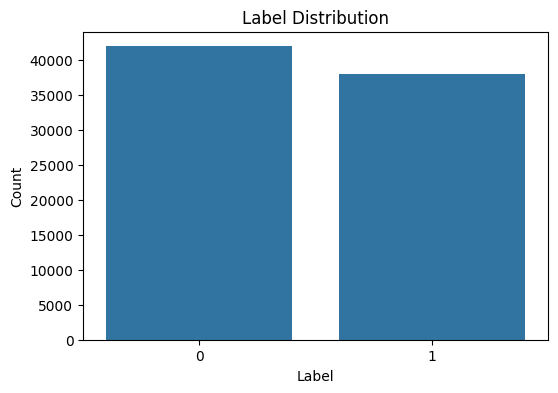

In [52]:
print("="*80)
print("TARGET DISTRIBUTION")
print("="*80)

label_counts = train_df["label"].value_counts(dropna=False).sort_index()
label_percent = train_df["label"].value_counts(normalize=True, dropna=False).sort_index() * 100

target_summary = pd.DataFrame({
    "count": label_counts,
    "percent": label_percent
})

display(target_summary)

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train_df)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Quick Numeric/Categorical Overview</h1>

In [53]:
print("="*80)
print("NUMERIC COLUMNS")
print("="*80)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

print("\n" + "="*80)
print("CATEGORICAL COLUMNS")
print("="*80)
categorical_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(categorical_cols)

print("\n" + "="*80)
print("NUMERIC SUMMARY")
print("="*80)
display(train_df.describe(include=[np.number]).T)

print("\n" + "="*80)
print("CATEGORICAL SUMMARY")
print("="*80)
display(train_df.describe(include=["object", "category", "bool"]).T)


NUMERIC COLUMNS
['label']

CATEGORICAL COLUMNS
['transaction_id', 'customer_id', 'transaction_timestamp', 'transaction_amount', 'payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']

NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
label,80000.0,0.475662,0.49941,0.0,0.0,0.0,1.0,1.0



CATEGORICAL SUMMARY


,count,unique,top,freq
transaction_id,80000,80000,T0024477,1
customer_id,80000,27937,C00353,12
transaction_timestamp,80000,80000,2026-02-16 19:56:24.183744,1
transaction_amount,78164.0,29733.0,-99.99,322.0
payment_method,79190,37,Debit Card,14710
device_type,79174,24,Mobile,24497
location,79184,38,Canada,12268
merchant_category,79193,41,Fashion,12340
is_international,80000,10,false,8115
transaction_frequency_24h,78608,184,3,5612


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Unique Values for Low-Cardinality Columns</h1>

In [54]:
print("="*80)
print("UNIQUE VALUES OF CATEGORICAL / LOW-CARDINALITY COLUMNS")
print("="*80)

for col in train_df.columns:
    n_unique = train_df[col].nunique(dropna=False)
    if n_unique <= 20:
        print(f"\nColumn: {col}")
        print(f"Unique values ({n_unique}):")
        print(train_df[col].value_counts(dropna=False))


UNIQUE VALUES OF CATEGORICAL / LOW-CARDINALITY COLUMNS

Column: is_international
Unique values (10):
is_international
false    8115
FALSE    8044
N        8027
0        8025
1        8020
Y        8016
TRUE     8013
true     7936
no       7917
yes      7887
Name: count, dtype: int64

Column: unusual_amount_flag
Unique values (10):
unusual_amount_flag
no       12499
FALSE    12382
0        12335
N        12260
false    12208
Y         3719
yes       3698
true      3666
1         3659
TRUE      3574
Name: count, dtype: int64

Column: multiple_transactions_short_time
Unique values (10):
multiple_transactions_short_time
no       9273
N        9214
FALSE    9179
0        9142
false    9075
TRUE     6936
1        6870
yes      6861
Y        6743
true     6707
Name: count, dtype: int64

Column: high_risk_device_flag
Unique values (10):
high_risk_device_flag
false    14609
N        14449
FALSE    14435
no       14307
0        14183
true      1675
yes       1606
Y         1586
1         1582
TR

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Preprocessing helpers </h1>
(Data Cleaning + Feature Engineering + Imputation + One Hot Maper)

In [55]:
def to_bool01(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    return BOOL_MAP.get(s, np.nan)

def fit_target_encoder(X_tr: pd.DataFrame, y_tr: pd.Series, col: str, smoothing: float = 20.0):
    df = pd.DataFrame({col: X_tr[col], "y": y_tr})
    global_mean = df["y"].mean()
    stats = df.groupby(col)["y"].agg(["mean", "count"])
    stats["te"] = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
    mapping = stats["te"].to_dict()
    return mapping, float(global_mean)



def apply_target_encoder(X: pd.DataFrame, col: str, mapping: dict, global_mean: float, out_col: str):
    out = X[col].map(mapping).astype(float)
    out = out.fillna(global_mean)
    X[out_col] = out
    return X


def preprocess_fit_transform(X_train: pd.DataFrame, X_valid: pd.DataFrame, y_train=None):
    X_tr = X_train.copy()
    X_va = X_valid.copy()


    # 1) datetime features
    for df in (X_tr, X_va):
        df["transaction_timestamp"] = pd.to_datetime(df["transaction_timestamp"], errors="coerce")
        df["tx_dayofweek"] = df["transaction_timestamp"].dt.dayofweek
        df["tx_is_weekend"] = (df["tx_dayofweek"] >= 5).astype(float)
        df.drop(columns=["transaction_timestamp"], inplace=True)

    # 2) drop IDs
    for df in (X_tr, X_va):
        df.drop(columns=[c for c in drop_noise if c in df.columns], inplace=True)


    # 3) normalize boolean-like
    for col in bool_like_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = df[col].map(to_bool01).astype(float)


    # 4) numeric cast + sentinel->NaN
    for col in numeric_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                if col in sentinel_map:
                    df.loc[df[col] == sentinel_map[col], col] = np.nan


    # 5) clean categoricals
    for col in categorical_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.lower()
                df[col] = df[col].replace(["nan", "missing", "null", "none"], np.nan)


    # -------------------------
    # IMPORTANT FIX:
    # 6) Impute BASE columns FIRST (train medians / train modes)
    # -------------------------
    num_features = [c for c in X_tr.columns if X_tr[c].dtype != "object"]
    # median on TRAIN only
    med = X_tr[num_features].median()
    X_tr[num_features] = X_tr[num_features].fillna(med)
    X_va[num_features] = X_va[num_features].fillna(med)


    # impute categoricals
    for col in categorical_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna("missing_cat")
            X_va[col] = X_va[col].fillna("missing_cat")


    # 6.5) Target Encoding (fit on TRAIN fold only)
    # requires y_train
    te_cols = [c for c in ["location", "merchant_category"] if c in X_tr.columns]

    if te_cols:
        if y_train is None:
            raise ValueError("y_train must be provided for target encoding in training folds.")

        for col in te_cols:
            # ensure string
            X_tr[col] = X_tr[col].astype(str)
            X_va[col] = X_va[col].astype(str)
            mapping, gmean = fit_target_encoder(X_tr, y_train, col=col, smoothing=20.0)
            X_tr = apply_target_encoder(X_tr, col, mapping, gmean, out_col=f"{col}_te")
            X_va = apply_target_encoder(X_va, col, mapping, gmean, out_col=f"{col}_te")
            # drop original high-card col
            X_tr.drop(columns=[col], inplace=True)
            X_va.drop(columns=[col], inplace=True)


    # 7) feature engineering AFTER imputation (no NaN cascade)
    for df in (X_tr, X_va):
        df["amount_to_avg_ratio"] = df["transaction_amount"] / (df["avg_transaction_amount_7d"] + 1)
        df["failure_rate_24h"] = df["failed_transaction_count_24h"] / (df["transaction_frequency_24h"] + 1)
        df["is_new_account"] = (df["account_age_days"] < 30).astype(float)
        df["amount_minus_avg"] = df["transaction_amount"] - df["avg_transaction_amount_7d"]
        df["intl_and_unusual"] = df["is_international"] * df["unusual_amount_flag"]
        df["high_risk_device_speed"] = df["high_risk_device_flag"] * df["multiple_transactions_short_time"]
        df["amount_per_recent_tx"] = df["transaction_amount"] / (df["transaction_frequency_24h"] + 1)
        df["tx_frequency_per_age"] = df["transaction_frequency_24h"] / (df["account_age_days"] + 1)
        df["sudden_spike"] = (df["transaction_amount"] > 3 * (df["avg_transaction_amount_7d"] + 1)).astype(float)
        df["burst_and_high"] = ((df["transaction_frequency_24h"] > 10) &
                               (df["transaction_amount"] > df["avg_transaction_amount_7d"])).astype(float)


    # 8) log transform (safe)
    for col in ["transaction_amount", "avg_transaction_amount_7d"]:
        for df in (X_tr, X_va):
            df[col] = np.log1p(df[col].clip(lower=0))


    # 9) rare label + one-hot for the remaining low-card categoricals
    # (payment_method, device_type)
    cat_features = [c for c in ["payment_method", "device_type"] if c in X_tr.columns]
    for col in cat_features:
        freq = X_tr[col].value_counts(normalize=True)
        rare = freq[freq < 0.01].index
        X_tr[col] = X_tr[col].apply(lambda x: "other" if x in rare else x)
        X_va[col] = X_va[col].apply(lambda x: "other" if x in rare else x)

    X_tr = pd.get_dummies(X_tr, columns=cat_features, drop_first=True)
    X_va = pd.get_dummies(X_va, columns=cat_features, drop_first=True)
    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)
    return X_tr.astype(float), X_va.astype(float)

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Feature-Target Split</h1>

In [56]:
X_all_raw = train_df.drop(columns=["label"]).copy()
y_all = train_df["label"].copy()

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">XGBoost Stratified K-Fold CV with OOF Predictions and Threshold Tuning</h1>

In [59]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(X_all_raw), dtype=float)
auc_scores = []

# ---- CV loop: fill oof_pred ----
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all_raw, y_all), 1):
    X_tr_raw = X_all_raw.iloc[tr_idx].copy()
    X_va_raw = X_all_raw.iloc[va_idx].copy()
    y_tr = y_all.iloc[tr_idx].copy()
    y_va = y_all.iloc[va_idx].copy()

    X_tr, X_va = preprocess_fit_transform(X_tr_raw, X_va_raw, y_train=y_tr)

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.0,
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
    )

    model.fit(X_tr, y_tr)

    va_pred = model.predict_proba(X_va)[:, 1]
    oof_pred[va_idx] = va_pred

    fold_auc = roc_auc_score(y_va, va_pred)
    auc_scores.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.5f}")

print(f"Mean AUC: {np.mean(auc_scores):.5f} ± {np.std(auc_scores):.5f}")

# ---- Now compute global OOF metrics (correct place) ----
y_true = y_all.values
proba = oof_pred

print("OOF proba stats:", proba.min(), proba.max(), proba.mean())

auc_oof = roc_auc_score(y_true, proba)
print(f"ROC-AUC (OOF): {auc_oof:.5f}")

def metrics_at_threshold(thr: float):
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)   # sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    return thr, acc, prec, rec, spec, f1, mcc, kappa, (tn, fp, fn, tp)

# metrics @ 0.5
thr = 0.5
thr, acc, prec, rec, spec, f1, mcc, kappa, cm = metrics_at_threshold(thr)
tn, fp, fn, tp = cm
print(f"\nThreshold={thr}")
print(f"Accuracy={acc:.5f} Precision={prec:.5f} Recall={rec:.5f} Specificity={spec:.5f}")
print(f"F1={f1:.5f} MCC={mcc:.5f} Kappa={kappa:.5f}")
print("CM [[TN,FP],[FN,TP]] =", [[tn, fp], [fn, tp]])

# best threshold for F1
best = None
for thr in np.linspace(0.01, 0.99, 99):
    out = metrics_at_threshold(thr)
    if best is None or out[5] > best[5]:  # compare F1
        best = out

thr, acc, prec, rec, spec, f1, mcc, kappa, cm = best
tn, fp, fn, tp = cm
print(f"\nBest-F1 threshold={thr:.2f}  F1={f1:.5f}  P={prec:.5f}  R={rec:.5f}  Spec={spec:.5f}")
print("CM [[TN,FP],[FN,TP]] =", [[tn, fp], [fn, tp]])

Fold 1: AUC = 0.90994
Fold 2: AUC = 0.91424
Fold 3: AUC = 0.91395
Fold 4: AUC = 0.91340
Fold 5: AUC = 0.90963
Mean AUC: 0.91223 ± 0.00202
OOF proba stats: 3.0216675440897234e-05 0.9999948740005493 0.47562610112393433
ROC-AUC (OOF): 0.91223

Threshold=0.5
Accuracy=0.79207 Precision=0.78832 Recall=0.76951 Specificity=0.81255
F1=0.77880 MCC=0.58285 Kappa=0.58270
CM [[TN,FP],[FN,TP]] = [[np.int64(34084), np.int64(7863)], [np.int64(8771), np.int64(29282)]]

Best-F1 threshold=0.30  F1=0.81816  P=0.69418  R=0.99606  Spec=0.60193
CM [[TN,FP],[FN,TP]] = [[np.int64(25249), np.int64(16698)], [np.int64(150), np.int64(37903)]]


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Top-10 Feature Importance Plot</h1>

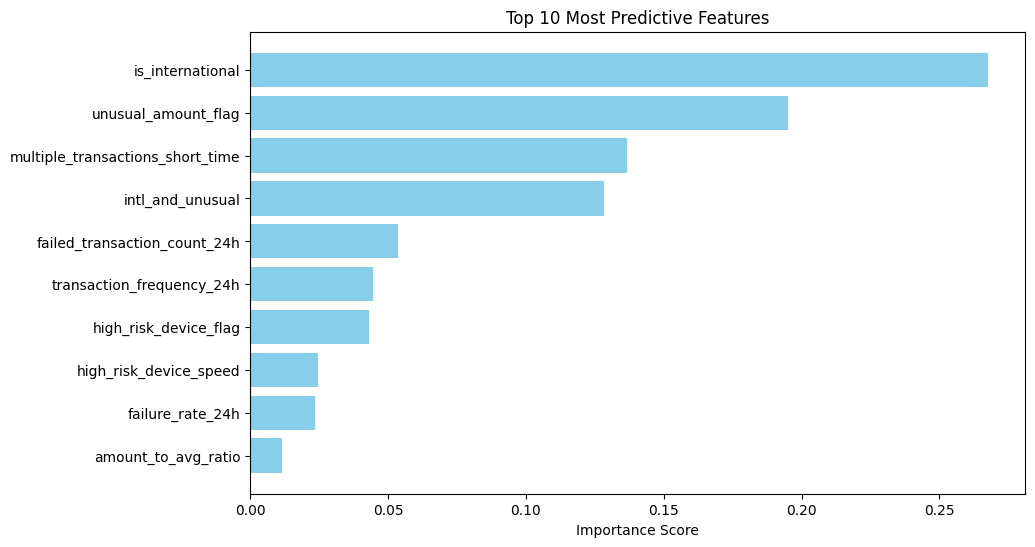

In [60]:
importances = model.feature_importances_
feature_names = X_tr.columns

feature_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['feature'].head(10), feature_imp_df['importance'].head(10), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Predictive Features')
plt.gca().invert_yaxis()
plt.show()

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Final XGBoost Training and Submission Generation</h1>

In [61]:
X_train_raw = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(int)

X_test_raw = cv_df.copy()
X_train, X_test = preprocess_fit_transform(X_train_raw, X_test_raw, y_train=y_train)

THR = 0.3

# ---- model (best params) ----
model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    reg_alpha=0.0,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

model.fit(X_train, y_train)

# ---- predict ----
test_proba = model.predict_proba(X_test)[:, 1]


test_pred = (test_proba >= THR).astype(int)

# ---- submission ----
sub = pd.DataFrame({
    IDCOL: cv_df[IDCOL].values,
    TARGET: test_pred
})

sub_path = "data/task1_dataset/submission.csv"
sub.to_csv(sub_path, index=False)

# optional: save probabilities for sanity-checking
proba_path = "data/task1_dataset/submission_with_proba.csv"
pd.DataFrame({IDCOL: cv_df[IDCOL].values, "proba": test_proba, TARGET: test_pred}).to_csv(proba_path, index=False)

print("Saved:", sub_path)
print("Also saved:", proba_path)
print("Pred positive rate:", test_pred.mean())
print("Proba stats:", float(test_proba.min()), float(test_proba.max()), float(test_proba.mean()))


Saved: data/task1_dataset/submission.csv
Also saved: data/task1_dataset/submission_with_proba.csv
Pred positive rate: 0.6857
Proba stats: 2.0902050891891122e-05 0.9999938011169434 0.4774312973022461
